Date: 4th August 2026

Author: Bipul Pandey

Objectives:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import sys
sys.path.append("../Scripts/")


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)

============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [2]:
### Hamming:
def Hamming_one_hot_encoded(Population, Ground_truth):
    Hamm=[]
    for p in Population:
        Diff = np.sum(np.abs((Ground_truth - p)), axis = 1) * 0.5
        ## smallest hamming difference
        Min_diff = np.min(Diff)
        Hamm.append(Min_diff)
    return np.array(Hamm)

def Minimum_Hamming_raw_data(Population, Ground_truth):
    Hamm=[]
    for p in Population:
        Diff = np.sum((Ground_truth != p), axis = 1)
        ## smallest hamming difference
        Min_diff = np.min(Diff)
        Hamm.append(Min_diff)
    return np.array(Hamm)

def Average_Hamming_raw_data(Population, Ground_truth):
    Hamm=[]
    for p in Population:
        Diff = np.sum((Ground_truth != p), axis = 1)
        ## smallest hamming difference
        Mean_diff = np.mean(Diff)
        Hamm.append(Mean_diff)
    return np.array(Hamm)



In [3]:
def Dataset_creator(Experiment):
    """Experiment: Integer 1 to 5:
        - 1 : Toy Model
        - 2 : MNIST
        - 3 : Sentences- Wikipedia
        - 4 : Sentences - Alice in Wonderland
        - 5 : Chorismate Mutase
        """

    Experiment = int(Experiment)

    if Experiment == 1:
        Exp_name = "Evolution Toy Model"
        print(Exp_name)
        GT_Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
        Gen_Data_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
        Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"

    if Experiment ==2:
        Exp_name = "MNIST"
        print(Exp_name)
        
        GT_Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
        Gen_Data_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
        Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"

    if Experiment == 3:
        Exp_name = "Sentences -Wikipedia"
        print(Exp_name)
        GT_Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
        Gen_Data_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
        Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"

    if Experiment == 4:
        Exp_name = "Sentences - Alice in Wonderland"
        print(Exp_name)
        GT_Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
        Gen_Data_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
        Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"

    if Experiment == 5:
        Exp_name = "Protein - Chorismate Mutase"
        print(Exp_name)
        GT_Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
        Gen_Data_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
        Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
        
    ### Lets put all of this in a dictionary

    Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")
    GT_Data = pd.read_csv(GT_Data_loc)
    Gen_Data= pd.read_csv(Gen_Data_loc)
    

    ## columns containing data
   
    columns = GT_Data.columns
    col_data = []
    for c in columns:
        if str.split(c, "-")[0] == 'Pos':
            col_data.append(c)
    ## ------
    Dataset = {}
    Dataset["Experiment"]= Exp_name
    Dataset["Partition_Map"] = Partition_Map
    Dataset["Training_Data"] = np.array(GT_Data[col_data])
    Dataset["Generated_Data"] = np.array(Gen_Data[col_data])

    Dataset["Training_Data_Size"] = len(GT_Data)
    Dataset["Generated_Data_Size"] = len(Gen_Data)

    return Dataset




In [4]:

def Proportional_Hamming_Analysis(Dataset , verbose = False):

    """Given a Datset This should construct a dataframe with Synthetic Data and Ground_truth data and their respective Hamming analysis"""

    #### --- load from Dataset ----
    Exp_name = Dataset["Experiment"]
    Partition_Map  = Dataset["Partition_Map"]
    GT_Data = Dataset["Training_Data"]
    Gen_Data = Dataset["Generated_Data"]

    #--------
    Proportional_Hamming_Array_Gen_Train ={}
    Raw_Hamming_Array_Gen_Train = {}
    #-------
    Proportional_Hamming_Array_Train_Train = {}
    Raw_Hamming_Array_Train_Train={}

    for p in range(0, len(Partition_Map)+1):

        if p< len(Partition_Map):
            ## Hamming analysis by partition
            partition_num = p
            Partition_name = "Partition-"+ str(p+1)
            Args_included = np.argwhere(Partition_Map[partition_num]==1).reshape(-1)
        else:
            ## Full dataset's hamming analysis
            Partition_name = "Full Dataset"
            Args_included = np.argwhere(np.sum(Partition_Map, axis = 0)==1).reshape(-1)


        GT_part = GT_Data[:, Args_included]
        Gen_part = Gen_Data[:, Args_included]

        Hamming_Dist_Gen_GT = Average_Hamming_raw_data(Gen_part, GT_part)
        Hamming_Dist_GT_GT = Average_Hamming_raw_data(GT_part, GT_part) 

        Proportional_Hamming_Array_Gen_Train[Partition_name] = Hamming_Dist_Gen_GT/len(Args_included)
        Proportional_Hamming_Array_Train_Train[Partition_name] = Hamming_Dist_GT_GT/len(Args_included)


        Raw_Hamming_Array_Gen_Train[Partition_name] = Hamming_Dist_Gen_GT
        Raw_Hamming_Array_Train_Train[Partition_name] = Hamming_Dist_GT_GT        

    Dataset["Proportional_Mean_Hamming_Gen_Train"] = Proportional_Hamming_Array_Gen_Train
    Dataset["Proportional_Mean_Hamming_Train_Train"] = Proportional_Hamming_Array_Train_Train

    if verbose:
        Dataset["Raw_Mean_Hamming_Gen_Train"] = Raw_Hamming_Array_Gen_Train
        Dataset["Raw_Mean_Hamming_Train_Train"] = Raw_Hamming_Array_Train_Train

    return Dataset


def Dataframe_for_violin_plot(Dataset_with_Proportional_Hamming):

    Gen_Data_hamm_property = Dataset_with_Proportional_Hamming["Proportional_Mean_Hamming_Gen_Train"]
    Train_Data_hamm_property = Dataset_with_Proportional_Hamming["Proportional_Mean_Hamming_Train_Train"]

    Len_gen = Dataset_with_Proportional_Hamming["Generated_Data_Size"]
    Len_train = Dataset_with_Proportional_Hamming["Training_Data_Size"]

    Origin_gen = np.array(["LRBM Generated"]* Len_gen)
    Origin_train = np.array(["Training Data"]* Len_train)
    Origin= np.concatenate([Origin_gen, Origin_train])

    df_gen = pd.DataFrame(Gen_Data_hamm_property)
    df_train = pd.DataFrame(Train_Data_hamm_property)

    df_full = pd.concat([df_gen,df_train], axis = 0, ignore_index=True)

    df_full["Origin"] = Origin

    return df_full



def Start_to_finish_dataframe( Experiment, verbose = False):
    """Experiment: Integer 1 to 5:
    - 1 : Toy Model
    - 2 : MNIST
    - 3 : Sentences- Wikipedia
    - 4 : Sentences - Alice in Wonderland
    - 5 : Chorismate Mutase
    """
    Experiment = int(Experiment)
    
    if Experiment<1 or Experiment >5:
        print("No Such Experiment! Please Choose between 1 and 5")
        print("Experiment: Integer 1 to 4:")
        print("- 1 : Toy Model : Evolution")
        print("- 2 : Images : MNIST")
        print("- 3 : Sentence: Wikipedia")
        print("- 4 : Sentence :Wikipedia")
        print("- 5 : Protein :Chorismate Mutase")
 
        return
    
    Dataset_start = Dataset_creator(Experiment)
    Dataset_start = Proportional_Hamming_Analysis(Dataset_start , verbose)

    Dataframe_dataset = Dataframe_for_violin_plot(Dataset_start)

    return Dataframe_dataset


def violin_plot(Data_frame, ax,Color_Palette = ["lightskyblue", "lightcoral"], include_Full = True, line_color = "grey", linewidth =1, width = 0.7, Legend = True):
    """Self-contained violin plot that draws onto a given ax."""

    X_vals = []
    Y_vals = []
    if include_Full:
        Key_Names = list(Data_frame.keys())[0:-1]
    else:
        Key_Names = list(Data_frame.keys())[0:-2]
        
    for i in range(0,len(Key_Names)):
        x = i+1
        y = Key_Names[i]

        X_vals.append(i)
        Y_vals.append(y)
        leg = True

        if i>0 or  Legend == False:
            leg = False

        sns.violinplot(data=Data_frame, x = x, y=y, hue="Origin", palette=Color_Palette, ax = ax, split=True, width = width, gap=.05, 
                    density_norm = 'width', common_norm=False, inner="quart", linewidth=linewidth, legend=leg, cut=0,linecolor=line_color)
        
    ax.grid(alpha = 0.5, zorder = 0)
        #plt.title(Exp_name)
    ax.set_xticks(X_vals)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xticklabels(labels=Y_vals)
    
    if Legend:
        ax.legend(loc = "lower right", fontsize = 10)
        ax.legend_.set_title("")
    # else:
    #    ax.legend(loc = "lower right", fontsize = 0)
    #    ax.legend_.set_title("")

    return ax

### Workflow:

In [5]:
DF_1 = Start_to_finish_dataframe(1)
DF_2 = Start_to_finish_dataframe(2)
DF_3 = Start_to_finish_dataframe(3)
DF_4 = Start_to_finish_dataframe(4)
DF_5 = Start_to_finish_dataframe(5)

Evolution Toy Model
MNIST
Sentences -Wikipedia
Sentences - Alice in Wonderland
Protein - Chorismate Mutase


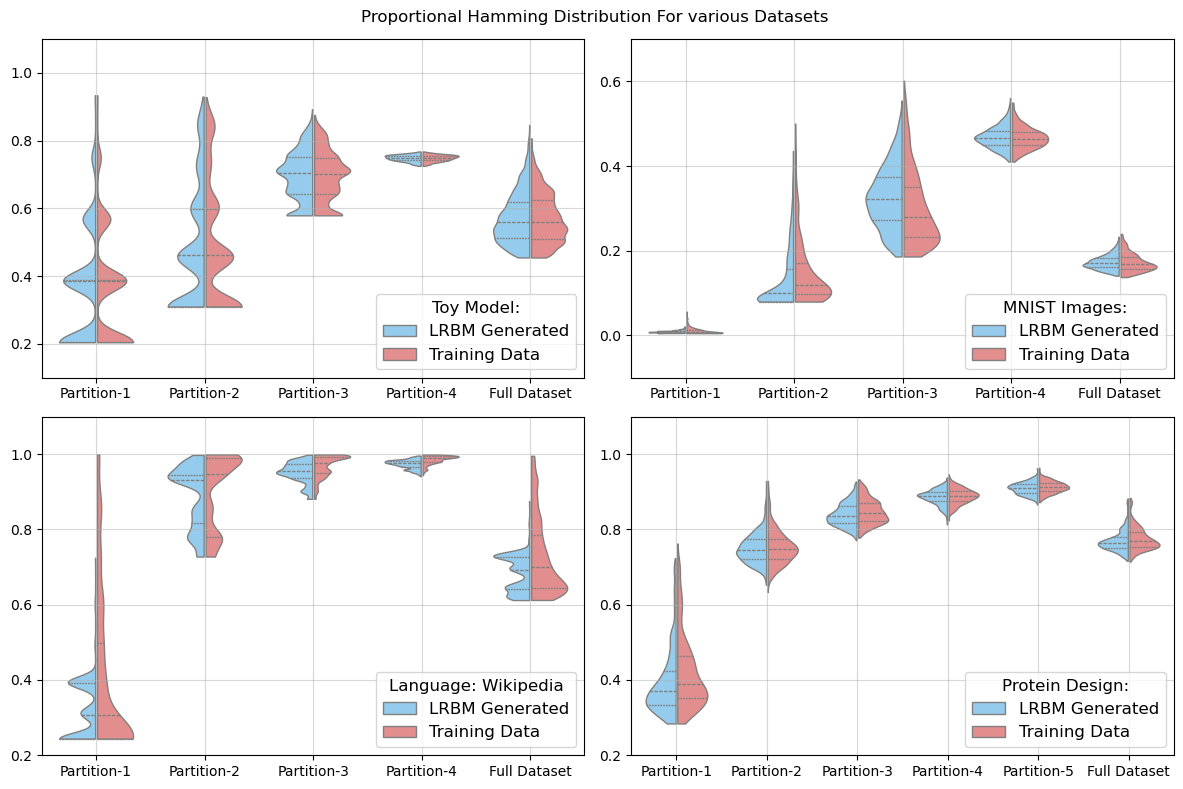

In [6]:
Title_fsize = 12
leg_fsize = 12
Inc_Full = True
fig, ax = plt.subplots(2,2,figsize=(12,8))

violin_plot(DF_1, ax = ax[0,0], include_Full=Inc_Full)
violin_plot(DF_2, ax = ax[0,1], include_Full=Inc_Full)
violin_plot(DF_3, ax = ax[1,0], include_Full=Inc_Full)
violin_plot(DF_5, ax = ax[1,1], include_Full=Inc_Full)

ax[0,0].legend(title = "Toy Model:", fontsize = leg_fsize, title_fontsize = Title_fsize, loc = "lower right")
ax[0,1].legend(title = "MNIST Images:", fontsize = leg_fsize, title_fontsize = Title_fsize,loc = "lower right")
ax[1,0].legend(title = "Language: Wikipedia", fontsize = leg_fsize, title_fontsize = Title_fsize,loc = "lower right")
ax[1,1].legend(title = "Protein Design:", fontsize = leg_fsize, title_fontsize = Title_fsize,loc = "lower right")


ax[0,0].set_yticks([0,0.2,0.4,0.6,0.8,1.0])
ax[0,1].set_yticks([0,0.2,0.4,0.6,0.8,1.0])
ax[1,0].set_yticks([0,0.2,0.4,0.6,0.8,1.0])
ax[1,1].set_yticks([0,0.2,0.4,0.6,0.8,1.0])

ax[0,0].set_ylim(0.1,1.1)
ax[0,1].set_ylim(-0.1,0.7)
ax[1,0].set_ylim(0.2,1.1)
ax[1,1].set_ylim(0.2,1.1)
plt.suptitle("Proportional Hamming Distribution For various Datasets")
plt.tight_layout()
